In [ ]:
!pip install pandas matplotlib seaborn torch

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


# Define column names
index_names = ['unit_number', 'time_cycles']
setting_names = ['setting_1', 'setting_2', 'setting_3']
sensor_names = [f'sensor_{i}' for i in range(1, 22)]
col_names = index_names + setting_names + sensor_names
# Load the dataset
df = pd.read_csv('/train_FD001.txt', sep=r'\s+' , header=None , names = col_names)
# Create a mapping dictionary for readability
sensor_mapping = {
    'sensor_1': 'T2_Fan_Inlet_Temp',
    'sensor_2': 'T24_LPC_Outlet_Temp',
    'sensor_3': 'T30_HPC_Outlet_Temp',
    'sensor_4': 'T50_LPT_Outlet_Temp',
    'sensor_5': 'P2_Fan_Inlet_Press',
    'sensor_6': 'EPR_Engine_Press_Ratio',
    'sensor_7': 'P15_Bypass_Press',
    'sensor_8': 'P30_HPC_Outlet_Press',
    'sensor_9': 'Nf_Physical_Fan_Speed',
    'sensor_10': 'Nc_Physical_Core_Speed',
    'sensor_11': 'Wf_Fuel_Flow',
    'sensor_12': 'Ps30_HPC_Outlet_Static_Press',
    'sensor_13': 'Phi_Fuel_Ratio',
    'sensor_14': 'NRf_Corrected_Fan_Speed',
    'sensor_15': 'NRc_Corrected_Core_Speed',
    'sensor_16': 'BPR_Bypass_Ratio',
    'sensor_17': 'farB_Burner_Fuel_Air_Ratio',
    'sensor_18': 'htBleed_Bleed_Enthalpy',
    'sensor_19': 'Nf_dmd_Demanded_Fan_Speed',
    'sensor_20': 'PCNf_dmd_Demanded_Corr_Fan_Speed',
    'sensor_21': 'P50_LPT_Outlet_Press'
}
max_cycles = df.groupby('unit_number')['time_cycles'].transform('max')
df['RUL'] = max_cycles - df['time_cycles']
# Rename columns after loading your dataframe
df.rename(columns=sensor_mapping, inplace=True)

In [5]:
stats = df[list(sensor_mapping.values())].describe().T
zero_var_sensors = stats[stats['std'] == 0].index.tolist()
print(f"Dropped Sensors with zero variance: {zero_var_sensors}")
df_new=df.drop(columns=zero_var_sensors)

Dropped Sensors with zero variance: ['htBleed_Bleed_Enthalpy', 'Nf_dmd_Demanded_Fan_Speed']


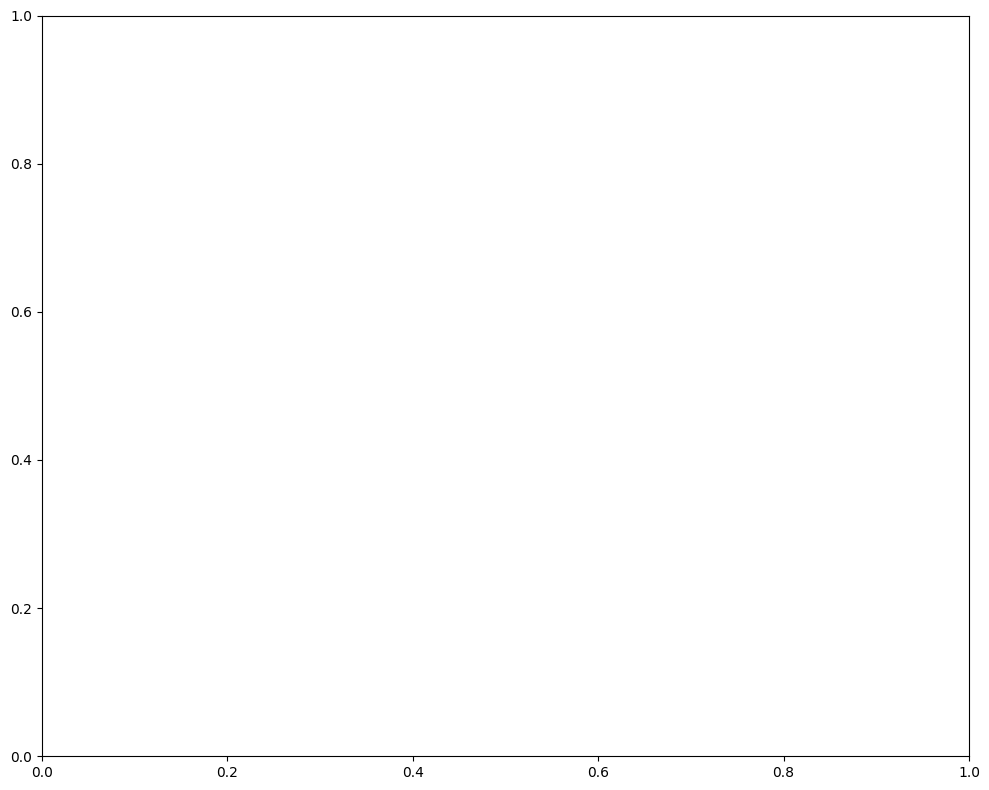

In [6]:
# Plot select sensors for Engine Unit 1 to see degradation trends
engine_1 = df[df['unit_number'] == 1]

fig, axes = plt.subplots(figsize=(10, 8))

plt.tight_layout()

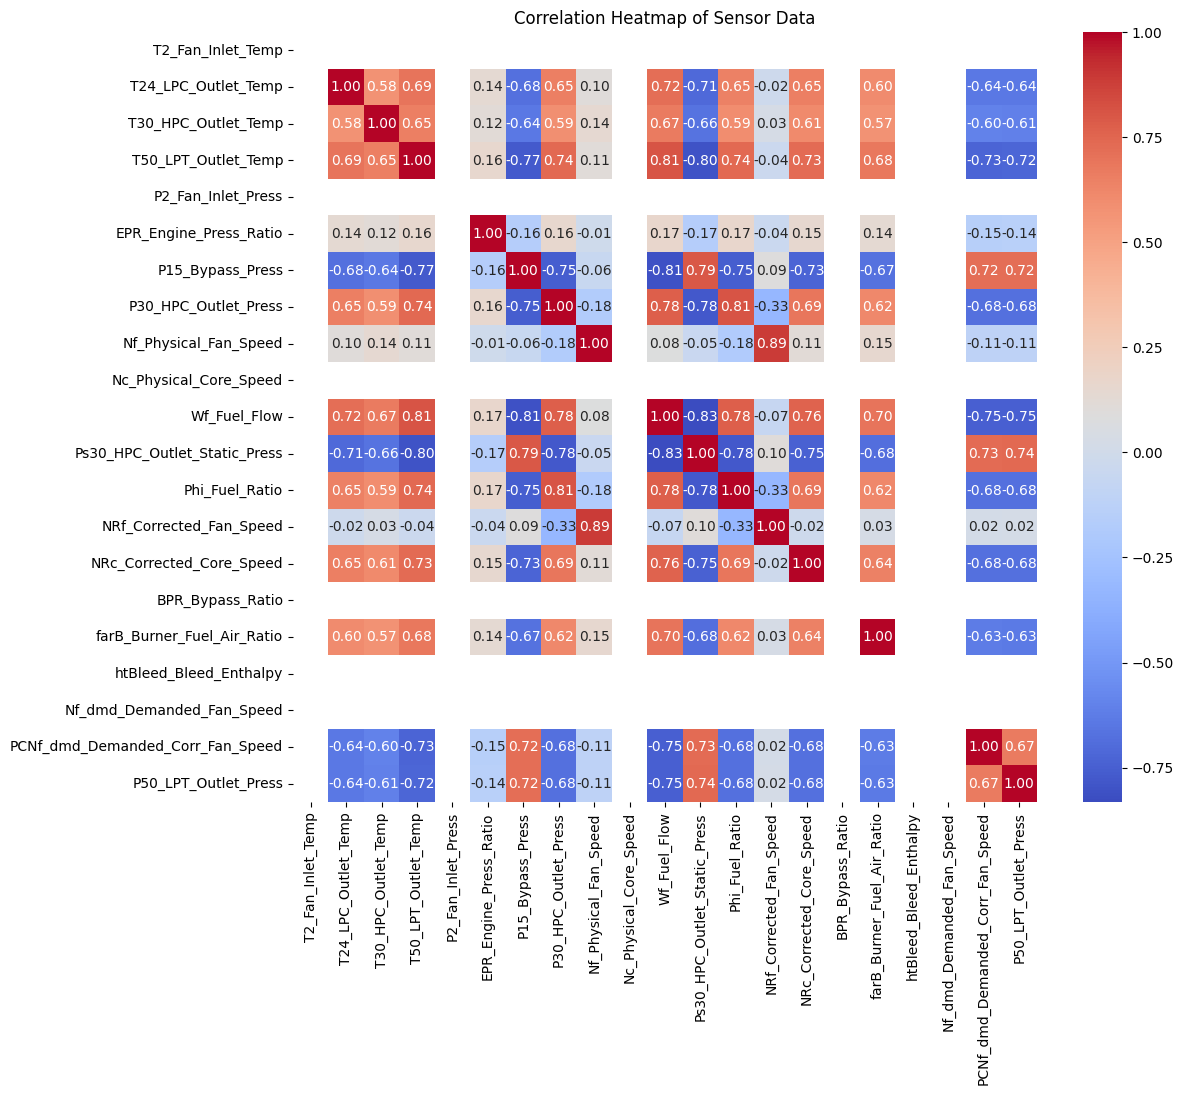

In [14]:
#Correlation heatmap for sensor data
plt.figure(figsize=(12, 10))
sns.heatmap(df[list(sensor_mapping.values())].corr(method='spearman'), annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Heatmap of Sensor Data')
plt.show()

In [15]:
#List out sensors with high correlation to reduce multicollinearity
correlation_matrix = df[list(sensor_mapping.values())].corr(method='spearman')
high_corr_pairs = []
threshold = 0.85
for i in range(len(correlation_matrix.columns)):
    for j in range(i):
        if abs(correlation_matrix.iloc[i, j]) > threshold:
            high_corr_pairs.append((correlation_matrix.columns[i], correlation_matrix.columns[j], correlation_matrix.iloc[i, j]))
print("Highly correlated sensor pairs (|correlation| > 0.85):")
for pair in high_corr_pairs:
    print(f"{pair[0]} and {pair[1]} with correlation {pair[2]:.2f}")



Highly correlated sensor pairs (|correlation| > 0.85):
NRf_Corrected_Fan_Speed and Nf_Physical_Fan_Speed with correlation 0.89


In [16]:
#We drop one of the highly correlated sensors to reduce multicollinearity
# Based on the correlation analysis, we can drop 'NRf_Corrected_Fan_Speed' due to its high correlation with 'Nf_Physical_Fan_Speed
df_final = df.drop(columns=['NRf_Corrected_Fan_Speed'])
print(df_final.shape[1])

26


In [10]:
# Check minimum cycles in training data for LSTM window
min_train_cycles = df.groupby('unit_number')['time_cycles'].max().min()
print(f"Shortest engine run in training data: {min_train_cycles} cycles")

Shortest engine run in training data: 128 cycles


LSTM Cell

In [12]:
import torch.nn as nn

class TurbofanLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers=1, dropout_prob=0.3):
        super(TurbofanLSTM, self).__init__()
        self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_size, num_layers=num_layers, batch_first=True,
                            dropout=dropout_prob if num_layers > 1 else 0)
        # Regularization layer to prevent overfitting
        self.dropout = nn.Dropout(dropout_prob)
        # Fully connected layer to output RUL prediction
        self.fc1 = nn.Linear(hidden_size, 16)
        self.relu = nn.ReLU()
        self.out = nn.Linear(16, 1)

    def forward(self, x):
        # x shape: (Batch Size, 30, 15)
        # LSTM output returns: (output, (hn, cn))
        lstm_out, (hn, cn) = self.lstm(x)
        last_time_step = lstm_out[:, -1, :]

        # pass through
        x = self.dropout(last_time_step)
        x = self.fc1(x)
        x = self.relu(x)
        rul_prediction = self.out(x)
        return rul_prediction.squeeze()

# Instantiate model
input_features = 25
hidden_dim = 64
model = TurbofanLSTM(input_size=input_features, hidden_size=hidden_dim, num_layers=2, dropout_prob=0.3)
print(model)


TurbofanLSTM(
  (lstm): LSTM(25, 64, num_layers=2, batch_first=True, dropout=0.3)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc1): Linear(in_features=64, out_features=16, bias=True)
  (relu): ReLU()
  (out): Linear(in_features=16, out_features=1, bias=True)
)


Load training dataset for training

In [17]:
from torch.utils.data import Dataset

class TurbofanDataset(Dataset):

    def __init__(self, dataframe, sequence_length=30):

        self.X = []
        self.y = []

        feature_columns = [
            c for c in dataframe.columns
            if c not in ['unit_number','time_cycles','RUL']
        ]

        for engine_id in dataframe['unit_number'].unique():

            engine_data = dataframe[
                dataframe['unit_number']==engine_id
            ]

            features = engine_data[feature_columns].values
            rul = engine_data['RUL'].values

            for i in range(len(engine_data)-sequence_length+1):

                self.X.append(
                    features[i:i+sequence_length]
                )

                self.y.append(
                    rul[i+sequence_length-1]
                )

        self.X = torch.tensor(self.X,dtype=torch.float32)
        self.y = torch.tensor(self.y,dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self,index):
        return self.X[index], self.y[index]